# Zadatak 1: Je li lako predvidjeti ocjenu filma na IMDB-u?
Istražite IMDb skup podataka i provjerite možete li predvidjeti filmski `Rating` iz dostupnih značajki. Za početak koristite jednostavnu linearnu regresiju za predviđanje značajke `Rating`, vizualizirajte podatke i model te izračunajte standardne metrike.

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

### TODO: Učitajte i pregledajte podatke
Učitajte IMDb skup podataka i kratko pogledajte nekoliko redaka kako bi se upoznali s značajkama.

In [65]:
data = pd.read_csv('IMDB-Movie-Data.csv')
data.head()

print(data.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Rank                1000 non-null   int64  
 1   Title               1000 non-null   object 
 2   Genre               1000 non-null   object 
 3   Description         1000 non-null   object 
 4   Director            1000 non-null   object 
 5   Actors              1000 non-null   object 
 6   Year                1000 non-null   int64  
 7   Runtime (Minutes)   1000 non-null   int64  
 8   Rating              1000 non-null   float64
 9   Votes               1000 non-null   int64  
 10  Revenue (Millions)  872 non-null    float64
 11  Metascore           936 non-null    float64
dtypes: float64(3), int64(4), object(5)
memory usage: 93.9+ KB
None


### TODO: Detaljnija inspekcija skupa i detektiranje nedostajućih vrijednosti
Provjeri info, oblik (shape) i nedostajuće vrijednosti da kako bi razumjeli kvalitetu i tipove podataka u skupu.

In [66]:
data.info()
data.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Rank                1000 non-null   int64  
 1   Title               1000 non-null   object 
 2   Genre               1000 non-null   object 
 3   Description         1000 non-null   object 
 4   Director            1000 non-null   object 
 5   Actors              1000 non-null   object 
 6   Year                1000 non-null   int64  
 7   Runtime (Minutes)   1000 non-null   int64  
 8   Rating              1000 non-null   float64
 9   Votes               1000 non-null   int64  
 10  Revenue (Millions)  872 non-null    float64
 11  Metascore           936 non-null    float64
dtypes: float64(3), int64(4), object(5)
memory usage: 93.9+ KB


(1000, 12)

### TODO: Pronađite ovisne varijable
Odaberit značajku koja je povezana s `Rating` značajkom. Ukratko objasnite zašto misliš da je dobar odabir i koliko će biti dobar odabir.

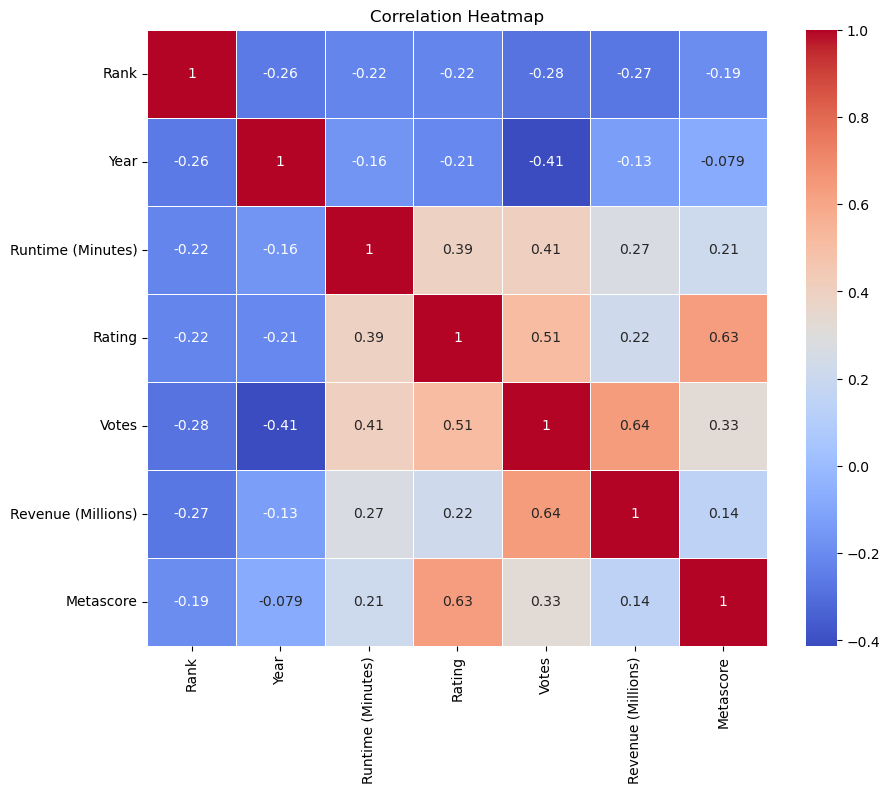

In [67]:
#heatmap for only in ints and floats
numeric_data = data.select_dtypes(include=[np.number])
correlation_matrix = numeric_data.corr()
plt.figure(figsize=(10, 8))
sbn.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()



### TODO: Vizualizirajte podatke i komentirajte što primjećujete (povežite s prethodnim)
Iscrtajte svoju odabranu značajku naspram `Rating`-a. Isprobajte opciju `alpha=0.5` kako bi bolje vidjeli gustoću podataka.

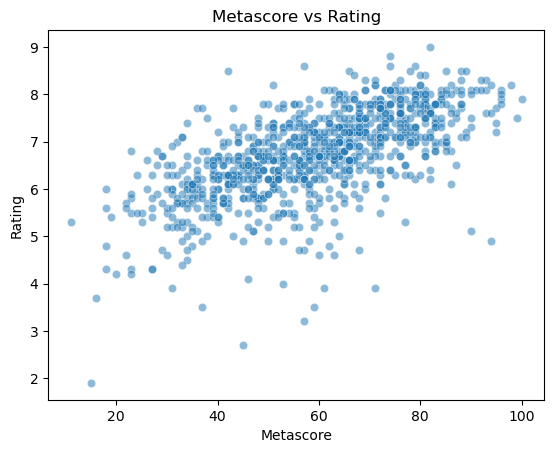

In [68]:
alpha=0.5
sbn.scatterplot(x='Metascore', y='Rating', data=data, alpha=alpha)
plt.xlabel('Metascore')
plt.ylabel('Rating')
plt.title('Metascore vs Rating')
plt.show()

### TODO: Natrenirajte model
Iskoristi odabranu značajku kao `X` i `Rating` kao `y`. Podijeli podatke na 80% za treniranje i 20% testiranje. Unutar podataka nalaze se vrijednosti koje nisu ispunjene, kako bi ih maknuli od cijelog skupa podataka odaberite dvije varijable koje će se koristiti (to možete tako da umjesto dohvaćanja jednog stupca, imena stavite u polje i dohvatite standardno), zatim na kraju dodate funkciju `dropna()`. Natrenirajte `LinearRegression` model na skupu za treniranje. (S obzirom na odabranu značajku razmislite je li potrebna standardizacija podataka).

In [69]:
# x = frequency , y  = rating 
data = pd.read_csv('IMDB-Movie-Data.csv')
dataclean=data[['Metascore', 'Rating']].dropna()
x=np.array(dataclean['Metascore'])
y=np.array(dataclean['Rating'])

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train = x_train.reshape(-1, 1)
x_test = x_test.reshape(-1, 1)
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)
model = LinearRegression()
model.fit(x_train, y_train)



LinearRegression()

### TODO: Nacrtajte fit line
Prikažite model na skupu za testiranje. Ručno odaberite par različitih ulaznih podataka i uz pomoć modela predvidite `Rating`.

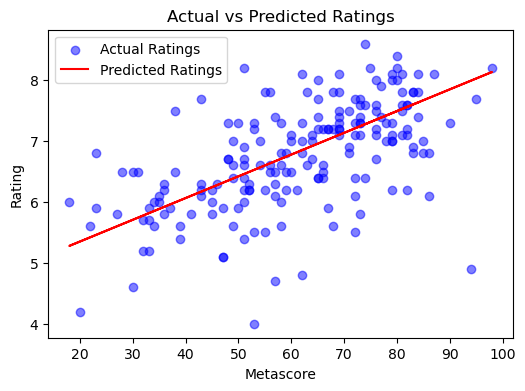

In [70]:
#rating prediction
plt.figure(figsize=(6, 4))
plt.scatter(x_test, y_test, color='blue', label='Actual Ratings', alpha=0.5)
y_pred = model.predict(x_test)
plt.plot(x_test, y_pred, color='red', label='Predicted Ratings')
plt.xlabel('Metascore')
plt.ylabel('Rating')
plt.title('Actual vs Predicted Ratings')
plt.legend()
plt.show()

### Metrike: procijenite točnost modela
Za ocjenjivanje linearnog modela koristimo dvije dopunske metrike: RMSE i $R^2$. Zajedno daju sliku i o apsolutnoj veličini pogreške i o tome koliko dobro model objašnjava varijabilnost u podacima.
- **RMSE (root mean squared error)**: $\operatorname{RMSE} = \sqrt{\tfrac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)^2}$. Mjeri prosječnu veličinu pogreške u istim jedinicama kao `Rating`, a kvadriranje jače kažnjava velika odstupanja. Niže je bolje.

- **$R^2$ (koeficijent determinacije)**: $R^2 = 1 - \tfrac{\sum_{i}(\hat{y}_i - y_i)^2}{\sum_{i}(y_i - \bar{y})^2}$. Pokazuje koliki dio varijance ciljne varijable model objašnjava u odnosu na predviđanje prosjekom. Vrijednost 1 je savršeno, 0 je kao pogađanje prosjeka, a negativno je lošije od prosjeka.
Izračunaj obje metrike na test skupu: niži RMSE i viši $R^2$ znače poželjniji model.

Donesite zaključak o modelu.

In [71]:
rmse = np.sqrt(mse)
print(f'Root Mean Squared Error: {rmse}')
yp=model.predict(x_test)
r2 = r2_score(y_test, yp)
print(f'R^2 Score: {r2}')


Root Mean Squared Error: 0.8738543173952371
R^2 Score: 0.3146704378647541


### Poboljšajte model
Za kraj napravite višestruku linearnu regresiju, izračunajte standardne metrike i usporedite ih s prvim modelom. Posebno ispišite utjecajte po značajkama za model, istražite kako iskoristiti funkciju `Series` iz pandas-a.


In [73]:
features=['Metascore', 'Votes', 'Revenue (Millions)', 'Runtime (Minutes)', 'Year']
data2=data[features]+['Rating'].dropna()

AttributeError: 'list' object has no attribute 'dropna'

# Zadatak 2 - Klasifikacija i perceptron algoritam

 - Zadani su podaci $\{x^{(1)}, x^{(2)}, \dots, x^{(m)}\} \subset \mathbb{R}^{n}$ i pripadne oznake/klase $y^{(i)} \in \{-1, 1\}$. 
 - Ideja perceptron algoritma je pronaći **hiperravninu** (potprostor dimenzije $n-1$) takav da se svi podaci s oznakom $1$ nalaze s jedne strane, a ostali s druge strane hiperravnine.
 - Hiperravnina je definirana vektorom $\Theta = [\theta_1, \dots, \theta_n]^T \in \mathbb{R}^n$ koji opisuje hiperravninu jednadžbom
 $$
 \Theta^Tx = \theta_1x_1 + \dots + \theta_nx_n = 0.
 $$
 - Ovako definirana hiperravnina prolazi kroz ishodište. Hiperravnina koja ne prolazi kroz ishodište ima dodatni *bias* parametar $\theta_0$ (kao i u modelu linearne regresije), a jednadžba postaje
 $$
 \theta_0 + \Theta^Tx = \theta_0 + \theta_1x_1 + \dots + \theta_nx_n = 0.
 $$
 - Za točke $x \in \mathbb{R}^n$ s oznakom 1 (s "gornje" strane hiperravnine) vrijedi $\theta_0 + \Theta{}^Tx > 0$, dok je za ostale $\theta_0 + \Theta{}x < 0$.
 - Vektor $\Theta$ je vektor normale na dobivenu hiperravninu.
 - U slučaju kad su točke $x^{(i)} \in \mathbb{R}^2$, hiperravnina koju tražimo je **pravac** opisan jednadžbom
 $$
 \theta_0 + \theta_1x + \theta_2y = 0,
 $$
 odnosno
 $$
 y = -\frac{\theta_1}{\theta_2}x - \frac{\theta_0}{\theta_2},
 $$
 ako je $\theta_2 \neq 0$.
- Što ako je $\theta_2 = 0$?

### Uvoz paketa za perceptron
Pripremamo `make_blobs` za generiranje sintetičkih binarnih skupova i `Perceptron` za jednostavni linearni klasifikator.

In [74]:
from sklearn.datasets import make_blobs
from sklearn.linear_model import Perceptron

### Generiranje i prikaz prvog razdvojivog skupa
Stvaramo dva jasno odvojena klastera i vizualiziramo ih kako bismo vidjeli linearnu razdvojivost.

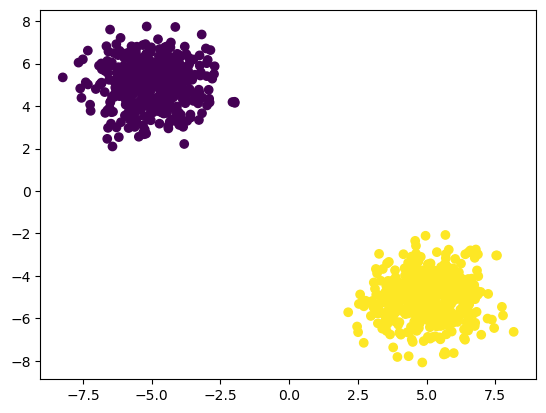

In [75]:
X, y = make_blobs(n_samples=1000, n_features=2, centers=[(-5, 5), (5, -5)])
y[y==0] = -1
plt.scatter(X[:,0], X[:,1], c = y)
plt.show()

### Treniranje perceptrona na prvom skupu
Fitamo perceptron s presjekom na prvom generiranom skupu.

In [ ]:
model = Perceptron(fit_intercept=True)
model.fit(X,y)
model.coef_, model.intercept_

### Granica odlučivanja za prvi skup
Izračunavamo pravac odlučivanja dobivenog modela i crtamo ga preko podataka.

In [ ]:
xx = np.linspace(np.min(X)-1, np.max(X)+1, 1000)
yy = -(model.coef_[0][0] / model.coef_[0][1]) * xx - (model.intercept_ / model.coef_[0][1])
plt.scatter(X[:,0], X[:,1], c=y)
plt.plot(xx, yy, color='crimson')
plt.show()

### Novi separabilni skup (udaljeni klasteri)
Stvaramo lakši primjer s klasterima u istom kvadrantu, daleko jedan od drugog.

In [ ]:
X, y = make_blobs(n_samples=1000, n_features=2, centers=[(5, 5), (15, 15)])
y[y==0] = -1
plt.scatter(X[:,0], X[:,1], c = y)
plt.show()

### Perceptron s presjekom na novom skupu
Uspostavljamo model na novom skupu i gledamo točnost.

In [76]:
model = Perceptron(fit_intercept=True)
model.fit(X, y)
model.coef_, model.intercept_
model.score(X, y)

1.0

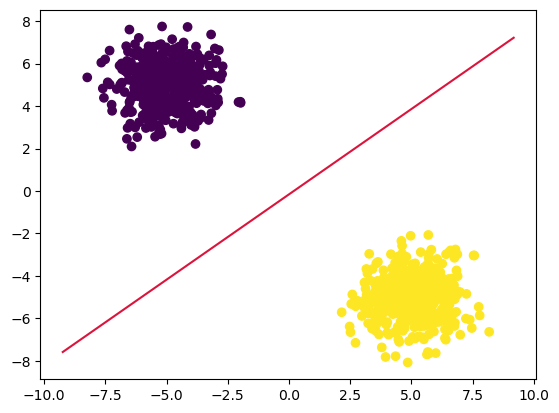

In [77]:
xx = np.linspace(np.min(X)-1, np.max(X)+1, 1000)
yy = -(model.coef_[0][0] / model.coef_[0][1]) * xx - (model.intercept_ / model.coef_[0][1])
plt.scatter(X[:,0], X[:,1], c=y)
plt.plot(xx, yy, color='crimson')
plt.show()

### Perceptron bez presjeka (usporedba)
Treniramo isti skup bez `bias` termina da usporedimo rezultate.

In [78]:
model = Perceptron(fit_intercept=False)
model.fit(X, y)
model.coef_, model.intercept_
model.score(X, y)

1.0

### Granica odlučivanja za model bez presjeka
Crtamo liniju odlučivanja modela bez presjeka na istim podacima.

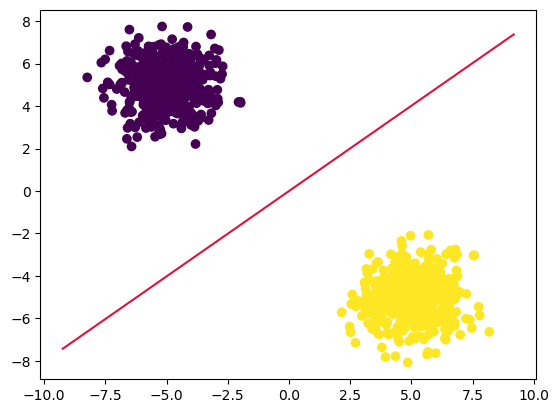

In [79]:
xx = np.linspace(np.min(X)-1, np.max(X)+1, 1000)
yy = -(model.coef_[0][0] / model.coef_[0][1]) * xx - (model.intercept_ / model.coef_[0][1])
plt.scatter(X[:,0], X[:,1], c=y)
plt.plot(xx, yy, color='crimson')
plt.show()

### Skup s preklapanjem (bliski klasteri)
Postavljamo klastere bliže jedan drugom kako bismo dobili djelomično razdvojive podatke.

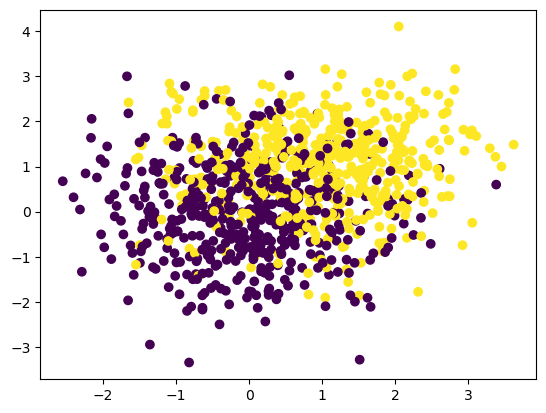

In [80]:
X, y = make_blobs(n_samples=1000, n_features=2, centers=[(0, 0), (1, 1)])
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

### Perceptron na djelomično razdvojivom skupu
Fitamo perceptron i gledamo koeficijente i točnost na skupu s preklapanjem.

In [81]:
model = Perceptron(fit_intercept=True)
model.fit(X, y)
model.coef_, model.intercept_, model.score(X, y)

(array([[2.74204336, 1.53595946]]), array([-1.]), 0.755)

### Granica odlučivanja u teškom slučaju
Vizualiziramo liniju odlučivanja modela na preklapajućem skupu podataka.

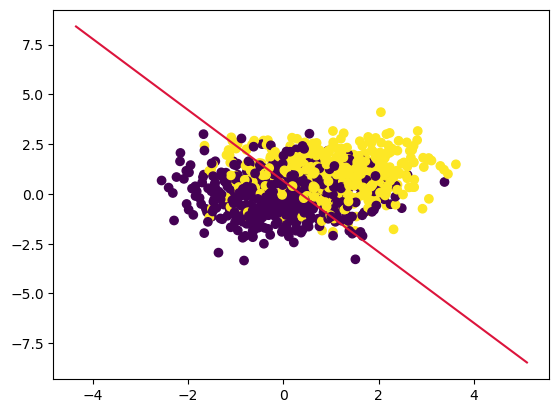

In [82]:
xx = np.linspace(np.min(X)-1, np.max(X)+1, 1000)
yy = -(model.coef_[0][0] / model.coef_[0][1]) * xx - (model.intercept_ / model.coef_[0][1])
plt.scatter(X[:,0], X[:,1], c=y)
plt.plot(xx, yy, color='crimson')
plt.show()